# **1. Introduction**

## 1.1 Project Overview

Time series forecasting is a critical tool in numerous domains, particularly in finance, where predicting future trends based on historical data can significantly influence decision-making. In this project, we employ a Recurrent Neural Network (RNN) to forecast Bitcoin (BTC) prices, leveraging its ability to model sequential data and capture temporal dependencies inherent in financial time series.

Bitcoin, being a highly volatile asset, presents both opportunities and risks for traders and investors. By analyzing historical OHLCV (Open, High, Low, Close, Volume) data, we aim to identify patterns that can help predict future price movements. The project involves selecting a target feature—such as price change or volatility—that serves as an indicator of potential profit or loss. The trained RNN model will then forecast this target value, assisting in identifying favorable market conditions or potential risks.

## 1.2 Dataset Overview

The dataset used in this project, BTC-USD.csv, contains daily Bitcoin price data, including key financial metrics. Each feature—Open, High, Low, Close, and Volume—provides essential insights into market behavior. Understanding these features and their calculations is crucial for preprocessing and model training.

# **2. Environment Setup**

## 2.1 Import Libraries

In [206]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import numpy as np
import tensorflow as tf

from matplotlib.dates import DateFormatter
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, LSTM, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

## 2.2 Configurations

In [207]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

tf.random.set_seed(42)

# **3. Dataset Loading**

In [159]:
bitcoin_df = pd.read_csv('BTC-USD.csv')

In [160]:
bitcoin_df.drop('Unnamed: 0', axis=1, inplace=True)

In [161]:
bitcoin_df['Date'] = pd.to_datetime(bitcoin_df['Date'])

The BTC-USD dataset contains OHLCV (Open, High, Low, Close, Volume) data, which is standard in financial markets. Here's how each column is calculated:



* 1. Open
  - **Definition:** The first recorded trade price of Bitcoin at the start of the trading day (00:00 UTC).  
  - **How It's Calculated:**  
    - Exchanges (e.g., Binance, Coinbase) track the first executed trade after midnight UTC.  
    - If no trades occur exactly at 00:00, the next available trade is taken.  


* 2. High
  - **Definition:** The highest price Bitcoin reached during the 24-hour trading day.  
  - **How It's Calculated:**  
    - Exchanges continuously record trade prices and update the daily high in real time.  
    - At the end of the day, the maximum observed price is stored.  


* 3. Low
  - **Definition:** The lowest price Bitcoin reached during the 24-hour trading day.  
  - **How It's Calculated:**  
    - Similar to the High, but tracks the **minimum** trade price within the same 24-hour window.  


* 4. Close
  - **Definition:** The last recorded trade price before the day ends (23:59:59 UTC).  
  - **How It's Calculated:**  
    - Some exchanges use a **closing auction** (like traditional markets).  
    - Others simply take the last executed trade before midnight.  

* 5. Volume
  - **Definition:** The total number of Bitcoin (BTC) traded in the 24-hour period.  
  - **How It's Calculated:**  
    - Sum of all BTC traded (buy/sell orders) across exchanges.  
    - **Not USD volume**—measured in BTC units.  
    - Some datasets adjust for wash trading (fake volume).  

---



Example Calculation (Hypothetical Day)

| Time  | Trade Price (USD) | Volume (BTC) |
|-------|-------------------|--------------|
| 00:00 | 50,000 (Open)     | 10           |
| 12:30 | 52,500 (High)     | 25           |
| 18:45 | 48,900 (Low)      | 30           |
| 23:59 | 51,200 (Close)    | 15           |
| **Total Volume** | **80 BTC** |

**Resulting OHLCV Row:**  
`Date, 50000, 52500, 48900, 51200, 80`


# **4. Exploratory Data Analysis (EDA) on OHLCV**

## 4.1 Dataset Overview

In [107]:
display(bitcoin_df.head())

,Date,Open,High,Low,Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100


In [108]:
bitcoin_df.describe()

,Date,Open,High,Low,Close,Volume
count,3222,3222.000000,3222.000000,3222.000000,3222.000000,3.222000e+03
mean,2019-02-13 11:59:59.999999744,13633.555524,13966.498897,13269.790975,13641.491658,1.657062e+10
min,2014-09-17 00:00:00,176.897003,211.731003,171.509995,178.102997,5.914570e+06
25%,2016-11-30 06:00:00,757.838730,772.024277,745.732499,759.970260,1.300485e+08
50%,2019-02-13 12:00:00,7664.044434,7867.845215,7499.634766,7679.053711,1.017502e+10
75%,2021-04-28 18:00:00,20210.792481,20660.277832,19811.524414,20238.632813,2.746342e+10
max,2023-07-13 00:00:00,67549.734375,68789.625000,66382.062500,67566.828125,3.509679e+11
std,NaN,16016.593310,16417.423832,15559.562019,16014.439000,1.950701e+10


In [109]:
print(f"BTC data from {bitcoin_df['Date'].min()} to {bitcoin_df['Date'].max()}")

BTC data from 2014-09-17 00:00:00 to 2023-07-13 00:00:00


## 4.2 OHLC Price Movement Over Time

We plot each column (Open, High, Low, Close, Volume) over
time.

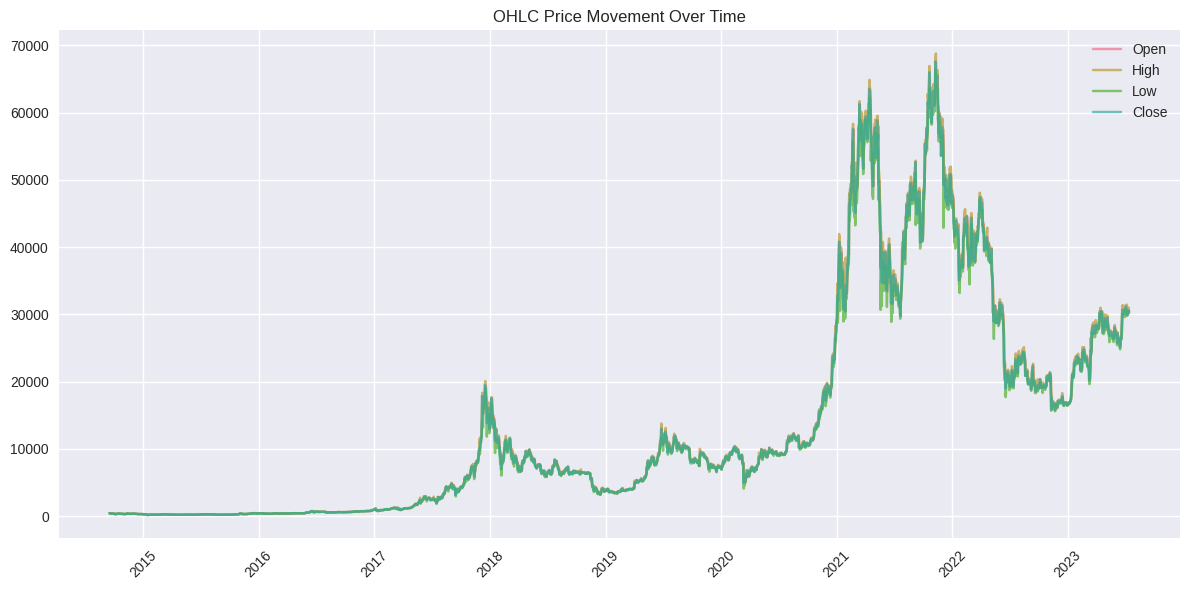

In [110]:
plt.figure(figsize=(12, 6))
plt.plot(bitcoin_df['Date'], bitcoin_df['Open'], label='Open', alpha=0.7)
plt.plot(bitcoin_df['Date'], bitcoin_df['High'], label='High', alpha=0.7)
plt.plot(bitcoin_df['Date'], bitcoin_df['Low'], label='Low', alpha=0.7)
plt.plot(bitcoin_df['Date'], bitcoin_df['Close'], label='Close', alpha=0.7)
plt.title('OHLC Price Movement Over Time')
plt.legend()
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 4.3 Volume Over Time

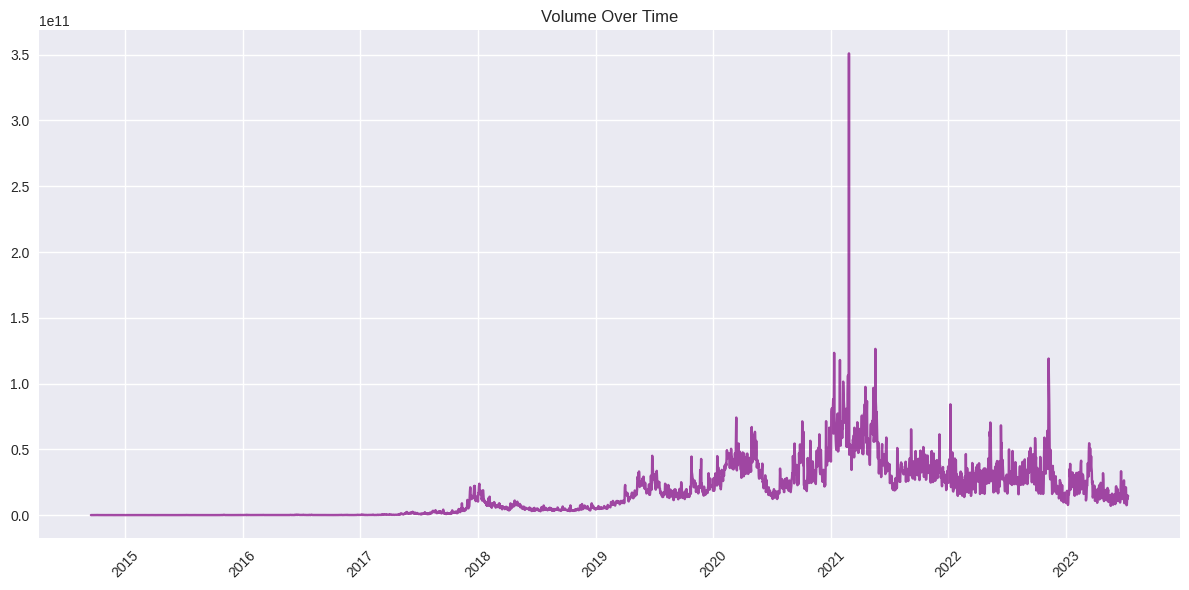

In [111]:
plt.figure(figsize=(12, 6))
plt.plot(bitcoin_df['Date'], bitcoin_df['Volume'], color='purple', alpha=0.7)
plt.title('Volume Over Time')
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 4.4 Correlation Analysis

In [112]:
corr_matrix = bitcoin_df[['Open', 'High', 'Low', 'Close', 'Volume']].corr()

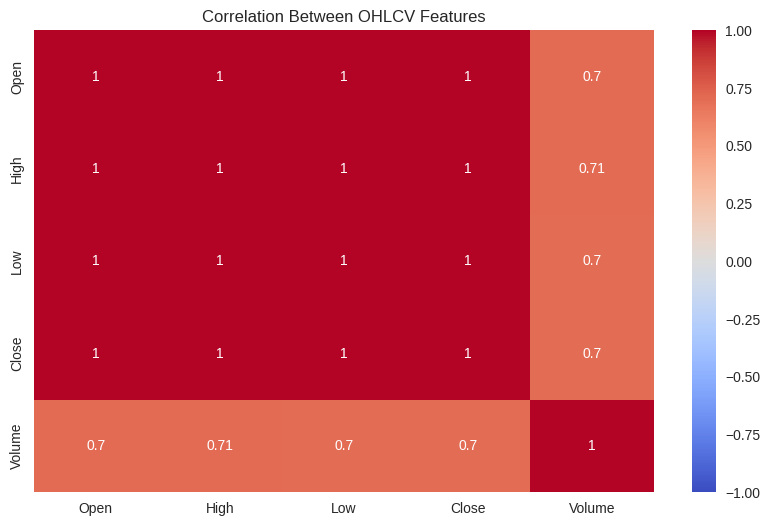

In [113]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Between OHLCV Features')
plt.show()

## 4.5 Close Price Distribution

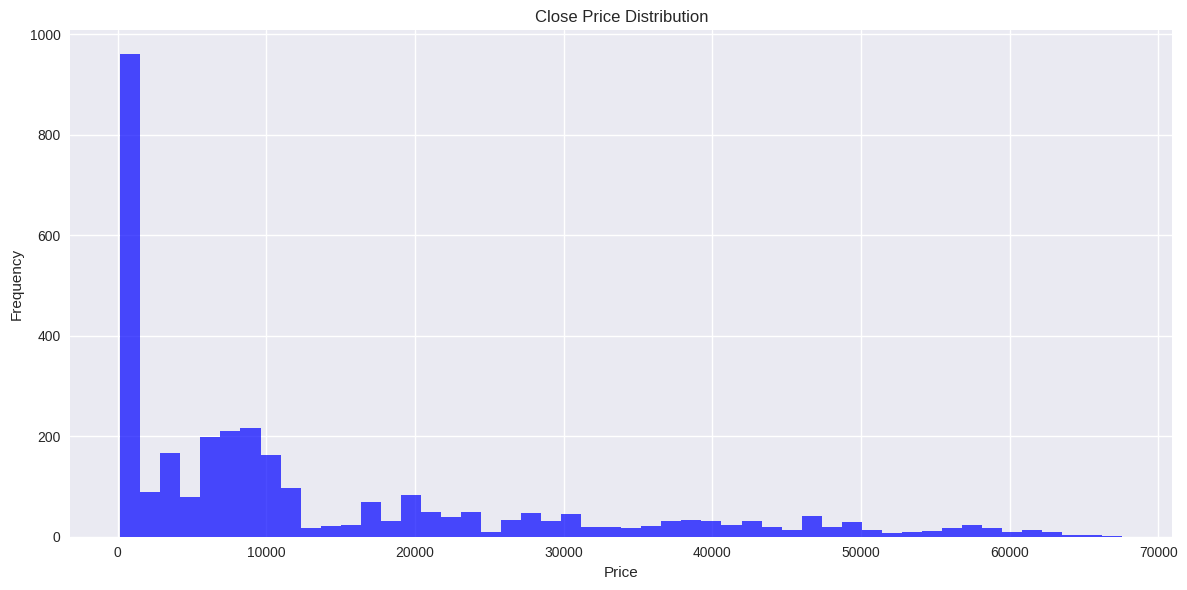

In [114]:
plt.figure(figsize=(12, 6))
plt.hist(bitcoin_df['Close'], bins=50, alpha=0.7, color='blue')
plt.title('Close Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 4.6 Daily Returns

### 4.6.1 Definition

The **daily return** measures the percentage change in an asset's price from one trading day to the next. It quantifies how much the price increased or decreased in a single day, expressed as a percentage.

$$
\text{Daily Return} = \frac{\text{Today's Close} - \text{Yesterday's Close}}{\text{Yesterday's Close}} \times 100\%
$$


- Measures short-term price volatility.
- Used to calculate cumulative returns, risk metrics (e.g., standard deviation), and performance comparisons.

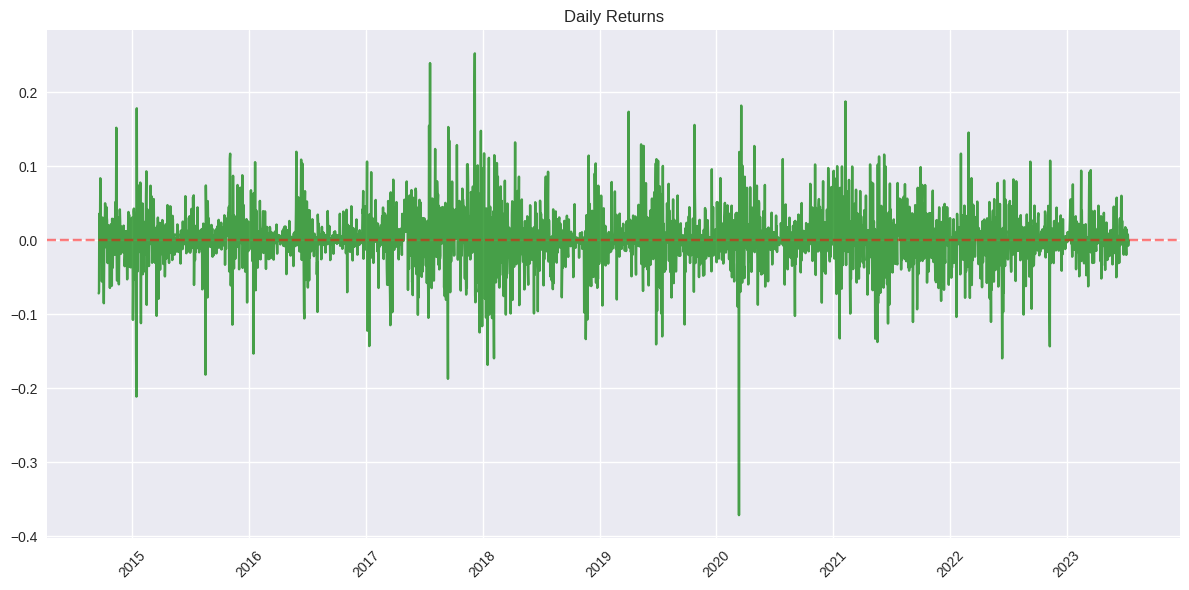

In [115]:
plt.figure(figsize=(12, 6))
daily_returns = bitcoin_df['Close'].pct_change().dropna()
plt.plot(bitcoin_df['Date'][1:], daily_returns, alpha=0.7, color='green')
plt.title('Daily Returns')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 4.6.2 Daily Returns Distribution

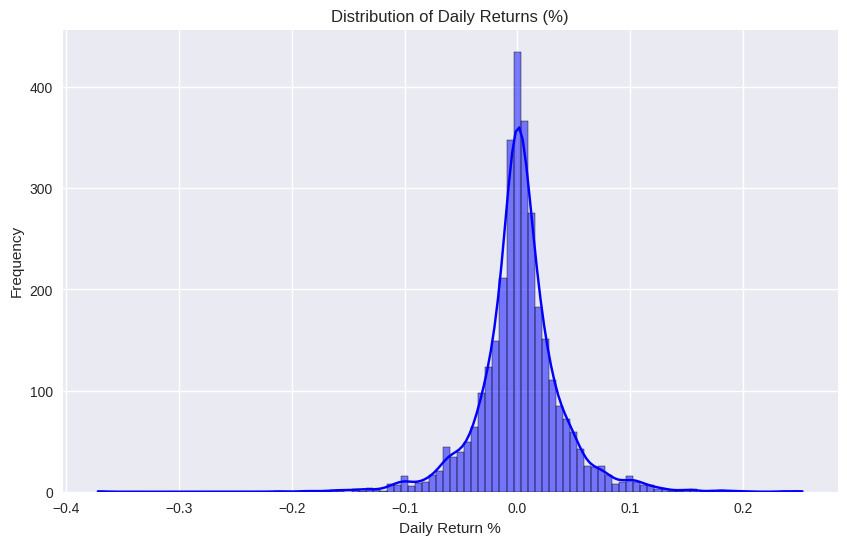

In [116]:
plt.figure(figsize=(10, 6))
sns.histplot(daily_returns.dropna(), bins=100, kde=True, color='blue')
plt.title('Distribution of Daily Returns (%)')
plt.xlabel('Daily Return %')
plt.ylabel('Frequency')
plt.show()

### 4.6.3 Daily Returns volatility

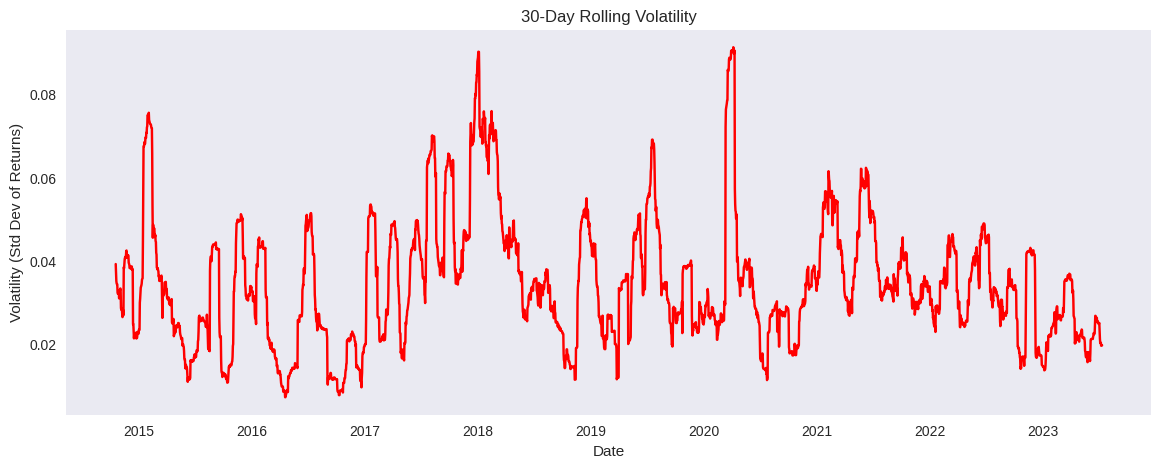

In [117]:
volatility = daily_returns.rolling(30).std()

plt.figure(figsize=(14, 5))
plt.plot(bitcoin_df['Date'][1:], volatility, color='red')
plt.title('30-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility (Std Dev of Returns)')
plt.grid()
plt.show()

# **5. Data Preprocessing**

In [162]:
bitcoin_df_copy = bitcoin_df.copy()

## 5.1 Handling Missing Data

In [141]:
bitcoin_df_copy.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0


## 5.2 Feature Engineering

### 5.2.1 Target Variable


```python
Composite_Signal = Future_Price_Change × ln(1 + Volume_Strength) × Volatility_Adjustment
```

**What it represents:**
- A **quality-adjusted profit signal** that predicts tomorrow's market opportunity
- Combines pure price movement with market confirmation factors
- Values closer to 0 = low/no opportunity, positive = profit opportunity, negative = risk/loss

**Mathematical Components:**
1. **Future_Price_Change**: `(Tomorrow_Close - Today_Close) / Today_Close`
2. **Volume_Strength**: `Tomorrow_Volume / 20_Day_Average_Volume`
3. **Volatility_Adjustment**: `1 / (1 + Recent_5Day_Volatility)`

**Why this target is superior:**
- **Market Quality Filter**: Not all price moves are equal - high-volume moves are more reliable
- **Risk Context**: Moves during stable periods are weighted higher than volatile noise
- **Trading Reality**: Mimics how professional traders evaluate opportunities
- **Actionable**: Directly indicates profit potential adjusted for market conditions

**Example Interpretation:**
- `Composite_Signal = 0.015` → Strong buy signal (1.5% quality-adjusted gain expected)
- `Composite_Signal = -0.008` → Warning signal (0.8% quality-adjusted loss expected)
- `Composite_Signal = 0.001` → Neutral (low opportunity, stay out)


In [163]:
price_change = bitcoin_df_copy['Close'].pct_change().shift(-1)
volume_strength = (bitcoin_df_copy['Volume'] / bitcoin_df_copy['Volume'].rolling(20).mean()).shift(-1)
volatility_adj = 1 / (1 + bitcoin_df_copy['Close'].rolling(5).std().shift(-1))

bitcoin_df_copy['Composite_Signal'] = (price_change *
                                       np.log(1 + volume_strength) *
                                       volatility_adj)

In [164]:
target_col = 'Composite_Signal'

### 5.2.2 Input Features

**Open Price**
- **What**: Bitcoin's opening price at market start
- **Why it helps**: Shows overnight sentiment and gap movements
- **Trading insight**: Gaps between previous close and open indicate news/sentiment shifts

**High Price**
- **What**: Highest price reached during the day
- **Why it helps**: Shows buying pressure strength and resistance levels
- **Pattern recognition**: Consistent higher highs indicate uptrends

**Low Price**
- **What**: Lowest price reached during the day
- **Why it helps**: Shows selling pressure and support levels
- **Risk assessment**: Lower lows indicate weakening support

**Close Price**
- **What**: Final price at market close
- **Why it helps**: Most important price - determines daily P&L for traders
- **Trend analysis**: Series of closes shows primary trend direction

**Volume**
- **What**: Total Bitcoin traded during the day
- **Why it helps**: Confirms price movements (high volume = strong conviction)
- **Market insight**: Volume precedes price - institutional activity indicator


**Price_Range** - *Intraday Volatility Measure*
```python
Price_Range = (High - Low) / Close
```
- **What**: Daily trading range as percentage of closing price
- **Why it helps**: Measures market uncertainty and volatility
- **Trading logic**:
  - High values → Emotional/uncertain market
  - Low values → Stable, controlled trading
- **Prediction value**: Volatility often precedes breakouts or reversals

**Close_to_Open** - *Daily Momentum Indicator*
```python
Close_to_Open = (Close - Open) / Open
```
- **What**: Percentage change from open to close
- **Why it helps**: Shows who won the daily battle (buyers vs sellers)
- **Market psychology**:
  - Positive → Bulls dominated the session
  - Negative → Bears controlled the day
- **Momentum insight**: Consistent direction indicates trend strength

**Volume_MA** - *Trading Activity Trend*
```python
Volume_MA = 7-day moving average of Volume
```
- **What**: Smoothed volume trend over past week
- **Why it helps**:
  - Removes daily volume spikes/noise
  - Shows underlying institutional interest
  - Confirms trend sustainability
- **Market insight**: Rising Volume_MA = increasing participation/conviction
- **Divergence signals**: Price up + Volume_MA down = weak trend (potential reversal)

**Price_MA** - *Short-term Trend Filter*
```python
Price_MA = 7-day moving average of Close
```
- **What**: Average price over past week
- **Why it helps**:
  - **Trend identification**: Current price vs MA shows trend direction
  - **Support/Resistance**: MA acts as dynamic support/resistance level
  - **Noise reduction**: Smooths out daily fluctuations
- **Trading signals**:
  - Price > Price_MA → Uptrend (bullish bias)
  - Price < Price_MA → Downtrend (bearish bias)

**Volatility** - *Risk/Uncertainty Measure*
```python
Volatility = 7-day rolling standard deviation of Close
```
- **What**: Price stability measure over past week
- **Why it helps**:
  - **Risk assessment**: High volatility = higher prediction uncertainty
  - **Market regime detection**: Low volatility often precedes breakouts
  - **Position sizing**: Helps model understand when to be more/less confident
- **Market cycles**: Volatility clustering - high vol periods followed by high vol

---

**How Features Work Together for Prediction:**

**Multi-Dimensional Market View:**

**Price Action (OHLC):**
- Shows what happened to prices
- Reveals buying/selling pressure patterns
- Identifies trend direction and strength

**Volume Confirmation:**
- Validates price movements
- Shows institutional vs retail activity
- Confirms trend sustainability

**Technical Indicators:**
- **Momentum** (Close_to_Open): Short-term direction
- **Trend** (Price_MA): Medium-term direction  
- **Volatility** (Price_Range, Volatility): Risk/uncertainty levels
- **Activity** (Volume_MA): Market participation trends

**Feature Synergy Examples:**

**Bullish Setup:**
- Price > Price_MA (uptrend)
- Positive Close_to_Open (daily momentum)
- Volume_MA rising (increasing participation)
- Low Volatility (stable trend)
- Target likely: Positive Composite_Signal

**Bearish Setup:**
- Price < Price_MA (downtrend)
- Negative Close_to_Open (daily weakness)
- Volume_MA falling (decreasing interest)
- High Price_Range (uncertainty)
- Target likely: Negative Composite_Signal

**Uncertain/Neutral:**
- Mixed signals across features
- High Volatility (unpredictable)
- Volume_MA stable (no new conviction)
- Target likely: Near-zero Composite_Signal



In [165]:
bitcoin_df_copy['Price_Range'] = ((bitcoin_df_copy['High'] - bitcoin_df_copy['Low']) /
                                  bitcoin_df_copy['Close'])
bitcoin_df_copy['Close_to_Open'] = ((bitcoin_df_copy['Close'] - bitcoin_df_copy['Open']) /
                                    bitcoin_df_copy['Open'])
bitcoin_df_copy['Volume_MA'] = bitcoin_df_copy['Volume'].rolling(window=7).mean()
bitcoin_df_copy['Price_MA'] = bitcoin_df_copy['Close'].rolling(window=7).mean()
bitcoin_df_copy['Volatility'] = bitcoin_df_copy['Close'].rolling(window=7).std()

In [166]:
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Price_Range',
                'Close_to_Open', 'Volume_MA', 'Price_MA', 'Volatility']

In [167]:
bitcoin_df_copy = bitcoin_df_copy[:-1].dropna()

## 5.3 Sequence Creation and Lookback Period

Sequence creation, converts a raw time series (e.g., daily Bitcoin prices) into input-output pairs for supervised learning.

The lookback period (T) defines how much historical data the model sees to make a prediction (e.g., 30, 60, or 90 days).

In [147]:
def create_sequences(features, target, lookback_period):
  X, y = [], []

  for i in range(lookback_period, len(features)):
    X.append(features[i - lookback_period:i])
    y.append(target[i])

  return np.array(X), np.array(y)

In [148]:
lookback_periods = [30, 60, 90]

## 5.4 Split Train, Validation, Test and Normalization

1. VALIDATION SET (Model Development):
  - Used during model training for hyperparameter tuning
  - Helps select best model architecture and parameters
  - Prevents overfitting during training process
  - Allows iterative improvement and experimentation
  - Data scientist sees validation results many times
    
2. TEST SET (Final Evaluation):
  - Used ONLY ONCE for final model evaluation
  - Provides unbiased estimate of model performance
  - Simulates real-world deployment scenario
  - Data scientist should NOT see test results during development
  - Prevents data leakage and overfitting to evaluation data
    
3. PROBLEMS WITH ONLY TEST SET:
  - Risk of overfitting to test data through repeated evaluation
  - No reliable way to tune hyperparameters
  - Biased performance estimates
  - Cannot distinguish between model and parameter selection errors
    
4. THREE-SET APPROACH BENEFITS:
  - Training: Learn patterns
  - Validation: Select best model and parameters
  - Test: Provide honest performance estimate
  - Maintains statistical rigor
  - Ensures generalizable results
    
5. TIME SERIES SPECIFIC CONSIDERATIONS:
  - Temporal ordering preserved (no data leakage from future)
  - Validation period simulates real trading conditions
  - Test period represents true out-of-sample performance
  - Accounts for regime changes in market behavior
    
ANALOGY: Think of it like training for an exam:
- Training data = Study materials
- Validation data = Practice tests (see results, adjust study strategy)
- Test data = Final exam (one chance, no feedback until after)

In [170]:
features = bitcoin_df_copy[feature_cols].values
target = bitcoin_df_copy[target_col].values.reshape(-1, 1)

train_size = int(0.7 * len(features))
val_size = int(0.15 * len(features))

X_train, X_temp = features[:train_size], features[train_size:]
y_train, y_temp = target[:train_size], target[train_size:]
X_val, X_test = X_temp[:val_size], X_temp[val_size:]
y_val, y_test = y_temp[:val_size], y_temp[val_size:]

scaler_features = MinMaxScaler()
scaler_features.fit(X_train)

X_train_scaled = scaler_features.transform(X_train)
X_val_scaled = scaler_features.transform(X_val)
X_test_scaled = scaler_features.transform(X_test)

In [171]:
datasets = {}

for period in lookback_periods:

  X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, period)
  X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, period)
  X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, period)

  datasets[period] = {
      'X_train': X_train_seq, 'y_train': y_train_seq,
      'X_val': X_val_seq, 'y_val': y_val_seq,
      'X_test': X_test_seq, 'y_test': y_test_seq,
  }

# **6. Training Model**

In [211]:
def train_model(model, X_train, y_train, X_val, y_val):
  callbacks = [
      EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
      ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)
  ]

  history = model.fit(
      X_train, y_train,
      epochs=100,
      batch_size=32,
      validation_data=(X_val, y_val),
      callbacks=callbacks,
      verbose=1
  )

  plt.figure(figsize=(12, 4))

  plt.subplot(1, 2, 1)
  plt.plot(history.history['loss'], label='Training Loss')
  plt.plot(history.history['val_loss'], label='Validation Loss')
  plt.title('Training Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(history.history['mae'], label='Training MAE')
  plt.plot(history.history['val_mae'], label='Validation MAE')
  plt.title('Training MAE')
  plt.xlabel('Epoch')
  plt.ylabel('MAE')
  plt.legend()

  plt.tight_layout()
  plt.show()

  return model, history

# **7. Evaluation and Visualization**

In [198]:
def calculate_metrics(y_true, y_pred):
  y_true_orig = y_true.ravel()
  y_pred_orig = y_pred.ravel()

  mse = mean_squared_error(y_true_orig, y_pred_orig)
  rmse = np.sqrt(mse)
  mae = mean_absolute_error(y_true_orig, y_pred_orig)
  mape = np.mean(np.abs((y_true_orig - y_pred_orig) / (y_true_orig + 1e-8))) * 100
  ce = np.sum(y_true_orig - y_pred_orig)

  return {
      'MSE': mse,
      'RMSE': rmse,
      'MAE': mae,
      'MAPE': mape,
      'CE': ce
  }

In [193]:
def evaluate_and_visualize(model, X_train, y_train, X_test, y_test):
  train_pred = model.predict(X_train)
  test_pred = model.predict(X_test)

  train_metrics = calculate_metrics(y_train, train_pred.ravel())
  test_metrics = calculate_metrics(y_test, test_pred.ravel())

  print(f"\n--- Performance Metrics ---")
  print("TRAINING SET:")
  for metric, value in train_metrics.items():
    print(f"  {metric}: {value:.6f}")

  print("TEST SET:")
  for metric, value in test_metrics.items():
    print(f"  {metric}: {value:.6f}")

  print("\n--- Metric Explanations ---")
  print("• MSE: Mean Squared Error - average squared differences (penalizes large errors)")
  print("• RMSE: Root Mean Squared Error - MSE in original scale (interpretable)")
  print("• MAE: Mean Absolute Error - average absolute differences (robust to outliers)")
  print("• MAPE: Mean Absolute Percentage Error - error as percentage (scale-independent)")
  print("• CE: Cumulative Error - total bias in predictions (positive = underestimation)")

  fig, axes = plt.subplots(2, 2, figsize=(15, 10))
  fig.suptitle('Model Evaluation', fontsize=16)

  train_true_orig = y_train.ravel()
  train_pred_orig = train_pred.ravel()
  test_true_orig = y_test.ravel()
  test_pred_orig = test_pred.ravel()

  axes[0,0].plot(train_true_orig, label='Actual', alpha=0.7)
  axes[0,0].plot(train_pred_orig, label='Predicted', alpha=0.7)
  axes[0,0].set_title('Training Set: Predicted vs Actual')
  axes[0,0].legend()
  axes[0,0].set_ylabel('Future Return')

  axes[0,1].plot(test_true_orig, label='Actual', alpha=0.7)
  axes[0,1].plot(test_pred_orig, label='Predicted', alpha=0.7)
  axes[0,1].set_title('Test Set: Predicted vs Actual')
  axes[0,1].legend()
  axes[0,1].set_ylabel('Future Return')


  test_errors = test_true_orig - test_pred_orig
  axes[1,0].plot(test_errors, color='red', alpha=0.7)
  axes[1,0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
  axes[1,0].set_title('Prediction Errors Over Time (Test Set)')
  axes[1,0].set_ylabel('Error')
  axes[1,0].set_xlabel('Time')

  axes[1,1].hist(test_errors, bins=30, alpha=0.7, color='orange')
  axes[1,1].axvline(x=0, color='black', linestyle='--', alpha=0.5)
  axes[1,1].set_title('Error Distribution (Test Set)')
  axes[1,1].set_xlabel('Error')
  axes[1,1].set_ylabel('Frequency')

  plt.tight_layout()
  plt.show()

  return test_metrics, train_metrics

# **8. RNN Model**

An RNN is a type of neural network designed for sequential data (time series, text, speech, etc.). Unlike traditional neural networks that process inputs independently, RNNs have memory—they maintain a hidden state that captures information from previous time steps.

## 8.1 Model Architecture

In [197]:
def build_rnn_model(input_shape):
  model = Sequential([
      Input(shape=input_shape),
      SimpleRNN(64, return_sequences=True),
      Dropout(0.2),

      SimpleRNN(32, return_sequences=False),
      Dropout(0.2),

      Dense(16, activation='relu'),
      Dropout(0.1),
      Dense(1, activation='linear')
      ])

  model.compile(
      optimizer=Adam(learning_rate=0.001),
      loss='mse',
      metrics=['mae'])

  print("RNN Model Architecture:")
  model.summary()

  return model

## 8.2 Training and Evaluation


--- Training and Evaluation RNN for Lookback Period: 30 ---
RNN Model Architecture:


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_28 (SimpleRNN)       │ (None, 30, 64)         │         4,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_54 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_29 (SimpleRNN)       │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_55 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_56 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,449 (33.00 KB)

 Trainable params: 8,449 (33.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1106 - mae: 0.2404 - val_loss: 0.0197 - val_mae: 0.1332 - learning_rate: 0.0010
Epoch 2/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0229 - mae: 0.1178 - val_loss: 0.0572 - val_mae: 0.2352 - learning_rate: 0.0010
Epoch 3/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0169 - mae: 0.1006 - val_loss: 0.0725 - val_mae: 0.2656 - learning_rate: 0.0010
Epoch 4/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0160 - mae: 0.0964 - val_loss: 0.0586 - val_mae: 0.2384 - learning_rate: 0.0010
Epoch 5/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0133 - mae: 0.0870 - val_loss: 0.0497 - val_mae: 0.2192 - learning_rate: 0.0010
Epoch 6/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0115 - mae: 0.0791 - val_loss: 0.0594 - val_mae: 0.2372 - learning_rate: 0.0010
Epoch 7/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0109 - mae: 0.0783 - val_loss: 0.0538 - val_mae: 0.2276 - learning_rate: 0.0010
Epoch 

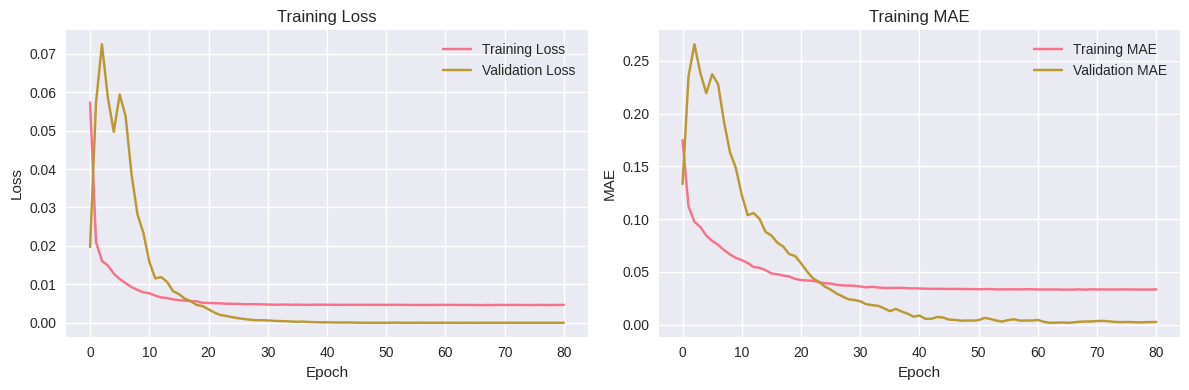

70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

--- Performance Metrics ---
TRAINING SET:
  MSE: 0.004620
  RMSE: 0.067970
  MAE: 0.032836
  MAPE: 2140170.038412
  CE: 3.674663
TEST SET:
  MSE: 0.000005
  RMSE: 0.002334
  MAE: 0.001817
  MAPE: 0.387482
  CE: 0.540917

--- Metric Explanations ---
• MSE: Mean Squared Error - average squared differences (penalizes large errors)
• RMSE: Root Mean Squared Error - MSE in original scale (interpretable)
• MAE: Mean Absolute Error - average absolute differences (robust to outliers)
• MAPE: Mean Absolute Percentage Error - error as percentage (scale-independent)
• CE: Cumulative Error - total bias in predictions (positive = underestimation)


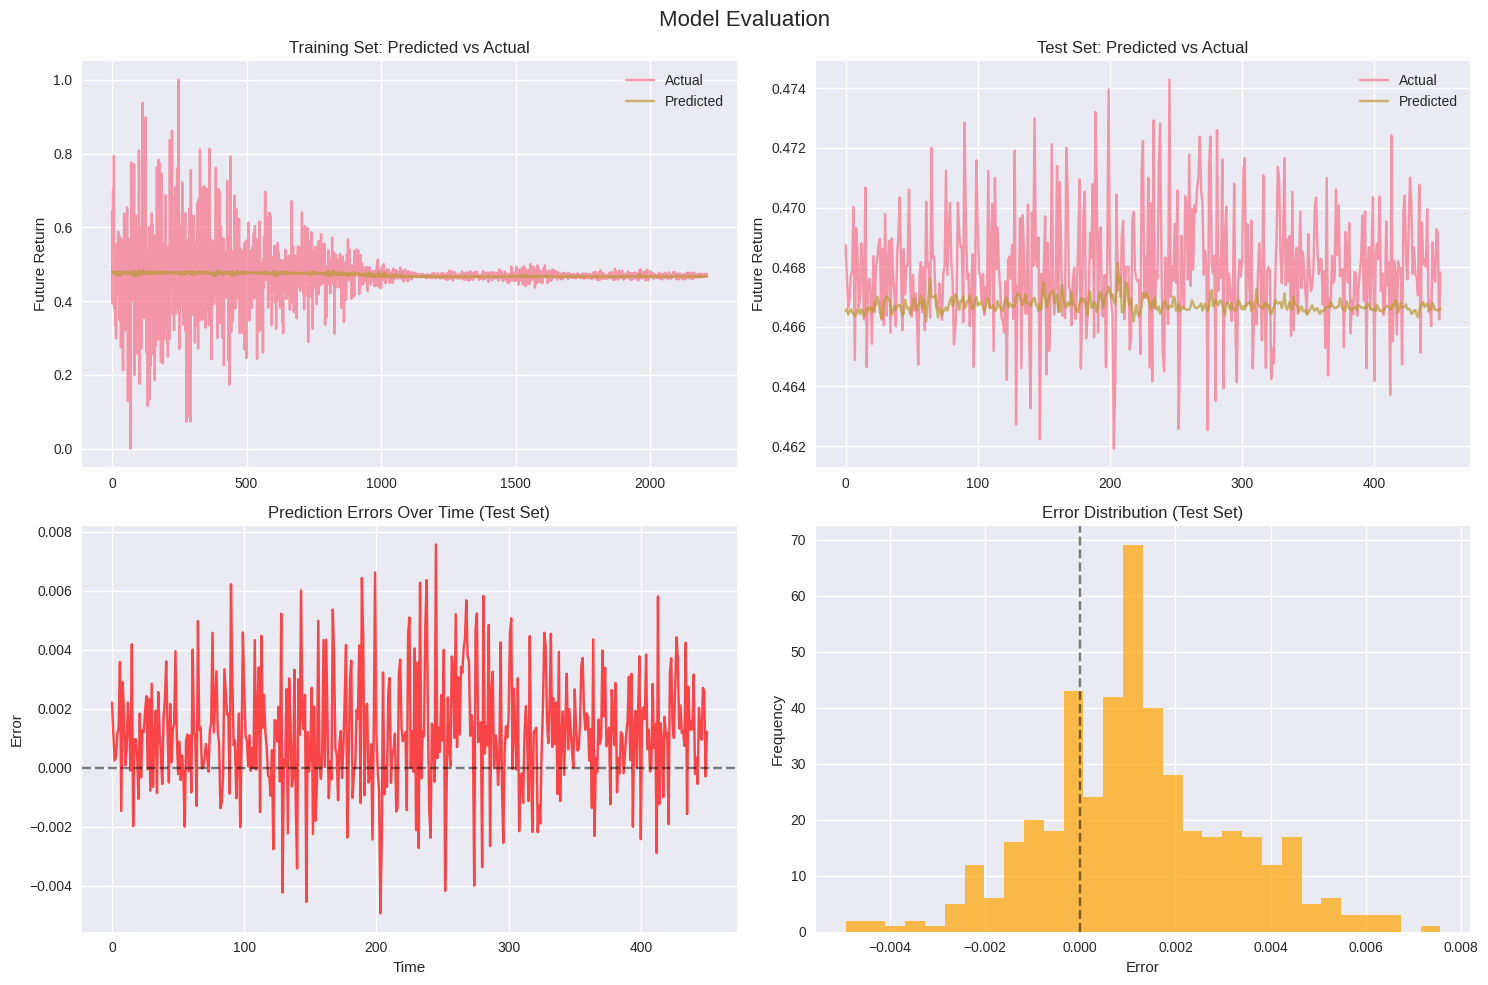


--- Training and Evaluation RNN for Lookback Period: 60 ---
RNN Model Architecture:


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_30 (SimpleRNN)       │ (None, 60, 64)         │         4,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_57 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_31 (SimpleRNN)       │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_58 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_59 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,449 (33.00 KB)

 Trainable params: 8,449 (33.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.1345 - mae: 0.2911 - val_loss: 0.0084 - val_mae: 0.0743 - learning_rate: 0.0010
Epoch 2/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0437 - mae: 0.1672 - val_loss: 0.0036 - val_mae: 0.0477 - learning_rate: 0.0010
Epoch 3/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0258 - mae: 0.1251 - val_loss: 0.0027 - val_mae: 0.0410 - learning_rate: 0.0010
Epoch 4/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0182 - mae: 0.1040 - val_loss: 0.0011 - val_mae: 0.0232 - learning_rate: 0.0010
Epoch 5/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0149 - mae: 0.0928 - val_loss: 0.0022 - val_mae: 0.0368 - learning_rate: 0.0010
Epoch 6/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0129 - mae: 0.0859 - val_loss: 0.0040 - val_mae: 0.0536 - learning_rate: 0.0010
Epoch 7/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0118 - mae: 0.0809 - val_loss: 0.0032 - val_mae: 0.0448 - learning_rate: 0.0010
Epoch 

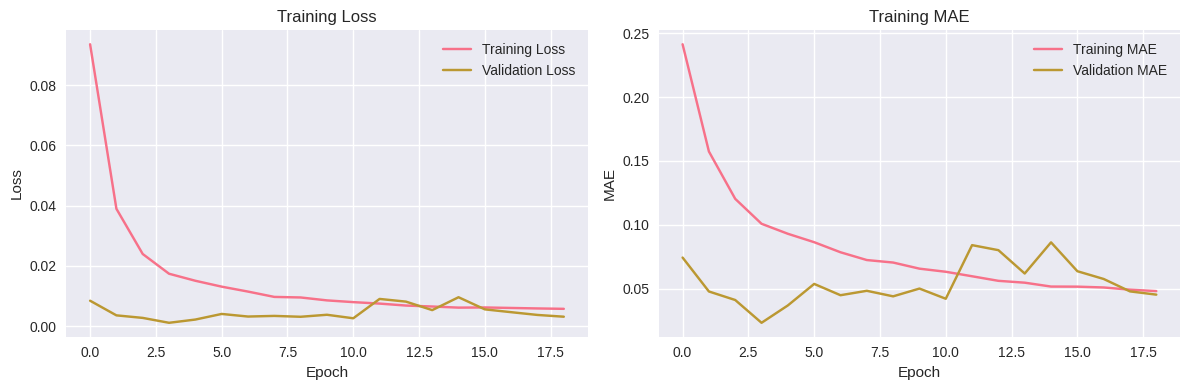

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

--- Performance Metrics ---
TRAINING SET:
  MSE: 0.008603
  RMSE: 0.092755
  MAE: 0.073654
  MAPE: 1927851.881692
  CE: 132.636843
TEST SET:
  MSE: 0.003861
  RMSE: 0.062133
  MAE: 0.057291
  MAPE: 12.239314
  CE: 23.997050

--- Metric Explanations ---
• MSE: Mean Squared Error - average squared differences (penalizes large errors)
• RMSE: Root Mean Squared Error - MSE in original scale (interpretable)
• MAE: Mean Absolute Error - average absolute differences (robust to outliers)
• MAPE: Mean Absolute Percentage Error - error as percentage (scale-independent)
• CE: Cumulative Error - total bias in predictions (positive = underestimation)


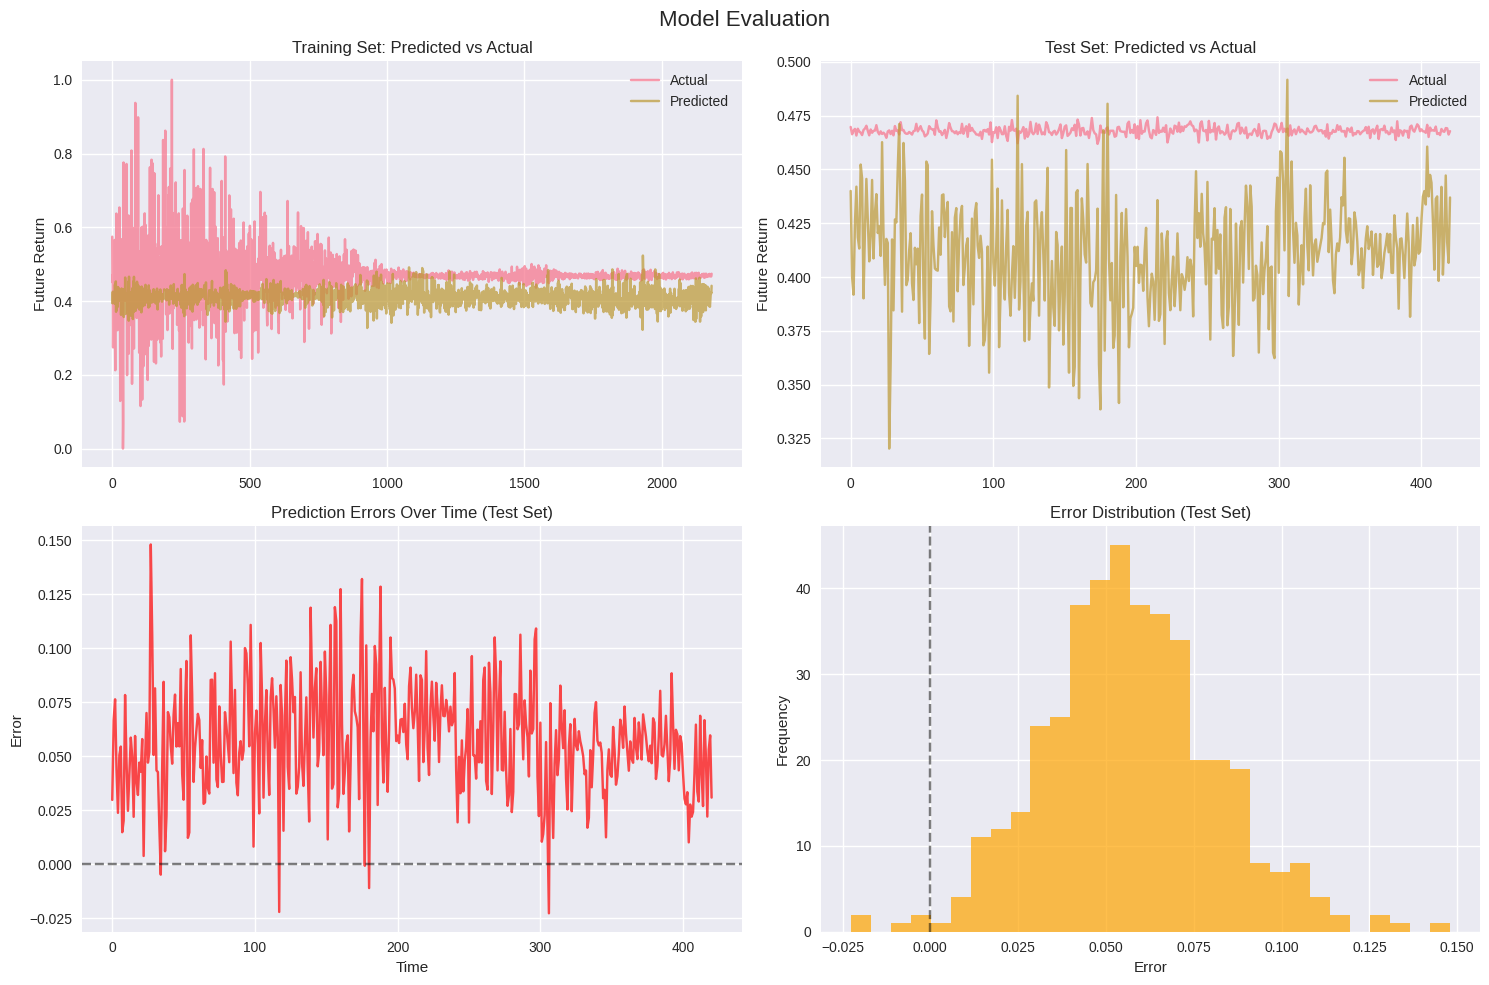


--- Training and Evaluation RNN for Lookback Period: 90 ---
RNN Model Architecture:


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_32 (SimpleRNN)       │ (None, 90, 64)         │         4,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_60 (Dropout)            │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_33 (SimpleRNN)       │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_61 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_62 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,449 (33.00 KB)

 Trainable params: 8,449 (33.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - loss: 0.1367 - mae: 0.2746 - val_loss: 0.0021 - val_mae: 0.0434 - learning_rate: 0.0010
Epoch 2/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0180 - mae: 0.1038 - val_loss: 0.0011 - val_mae: 0.0303 - learning_rate: 0.0010
Epoch 3/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 0.0152 - mae: 0.0948 - val_loss: 0.0012 - val_mae: 0.0297 - learning_rate: 0.0010
Epoch 4/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0141 - mae: 0.0895 - val_loss: 0.0013 - val_mae: 0.0320 - learning_rate: 0.0010
Epoch 5/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.0109 - mae: 0.0775 - val_loss: 0.0011 - val_mae: 0.0278 - learning_rate: 0.0010
Epoch 6/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - loss: 0.0100 - mae: 0.0735 - val_loss: 6.3899e-04 - val_mae: 0.0207 - learning_rate: 0.0010
Epoch 7/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0091 - mae: 0.0685 - val_loss: 0.0010 - val_mae: 0.0296 - learning_rate: 0.0010
Ep

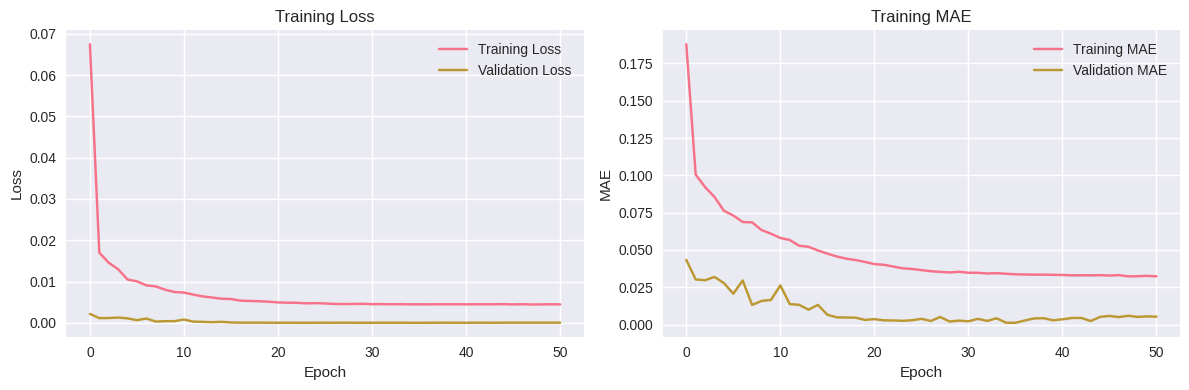

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

--- Performance Metrics ---
TRAINING SET:
  MSE: 0.004420
  RMSE: 0.066486
  MAE: 0.031444
  MAPE: 2188268.256012
  CE: 8.047563
TEST SET:
  MSE: 0.000005
  RMSE: 0.002266
  MAE: 0.001787
  MAPE: 0.381975
  CE: -0.089512

--- Metric Explanations ---
• MSE: Mean Squared Error - average squared differences (penalizes large errors)
• RMSE: Root Mean Squared Error - MSE in original scale (interpretable)
• MAE: Mean Absolute Error - average absolute differences (robust to outliers)
• MAPE: Mean Absolute Percentage Error - error as percentage (scale-independent)
• CE: Cumulative Error - total bias in predictions (positive = underestimation)


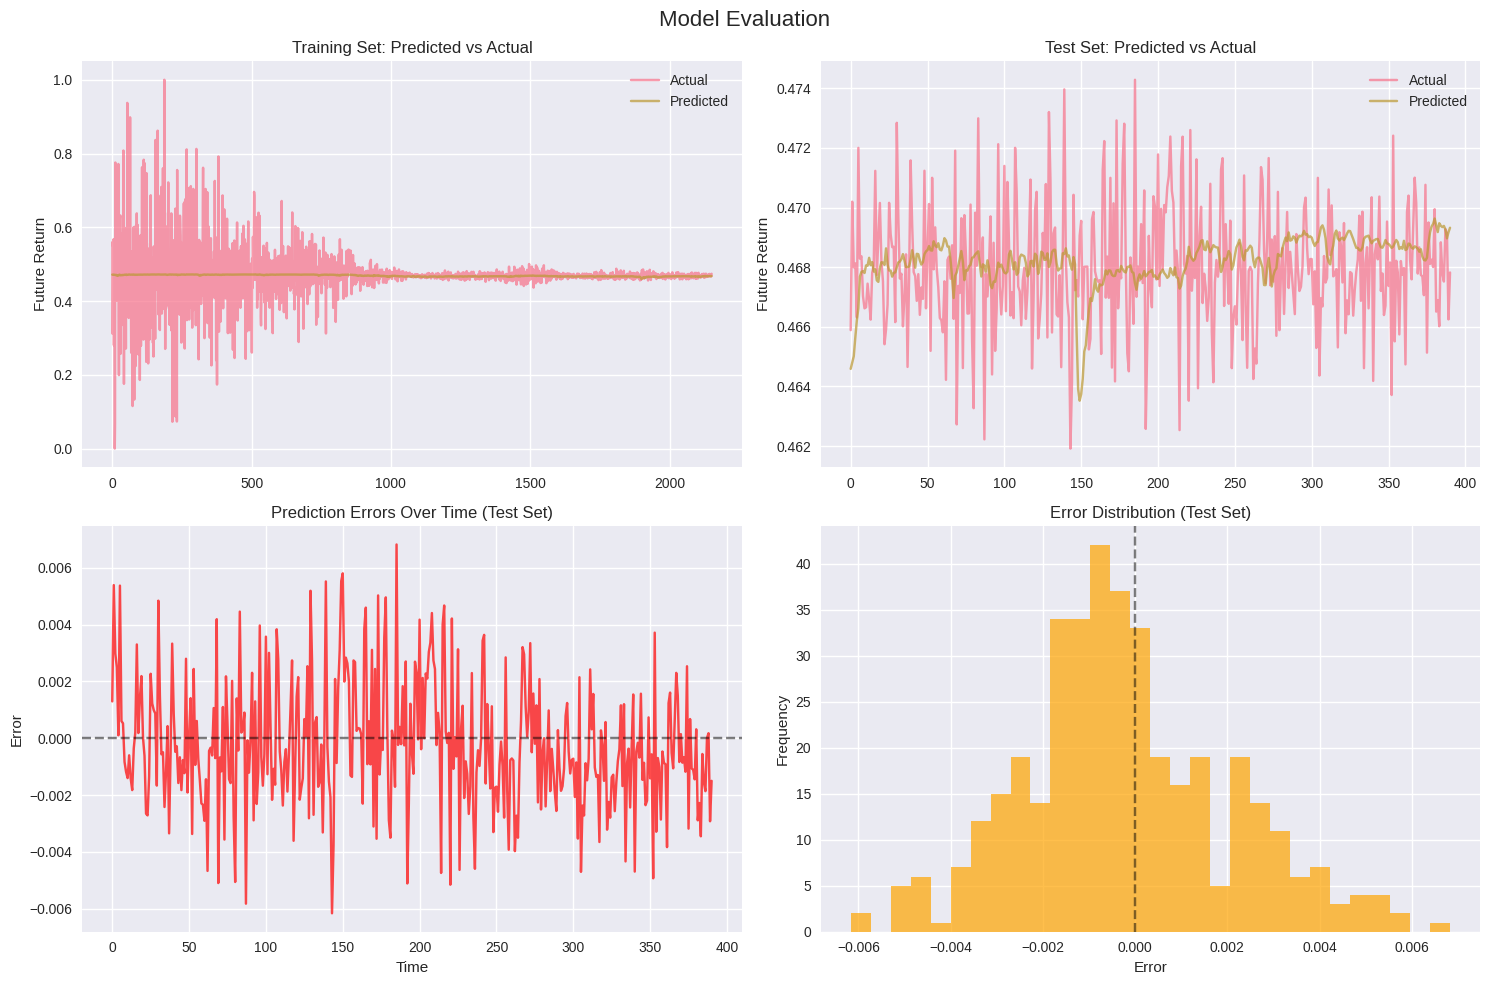

In [212]:
for period, data in datasets.items():
  X_train, y_train = data['X_train'], data['y_train']
  X_val, y_val = data['X_val'], data['y_val']
  X_test, y_test = data['X_test'], data['y_test']

  input_shape = (X_train.shape[1], X_train.shape[2])

  print(f"\n--- Training and Evaluation RNN for Lookback Period: {period} ---")

  rnn_model = build_rnn_model(input_shape)
  rnn_model, rnn_history = train_model(rnn_model,
                                       X_train,
                                       y_train,
                                       X_val,
                                       y_val)

  rnn_test_metrics, rnn_train_metrics = evaluate_and_visualize(rnn_model,
                                                               X_train,
                                                               y_train,
                                                               X_test,
                                                               y_test)

# **9. LSTM Model**

LSTM (Long Short-Term Memory) is a specialized type of Recurrent Neural Network (RNN) designed to capture long-term dependencies in sequential data (e.g., time series, text, speech). Unlike basic RNNs, LSTMs mitigate the vanishing gradient problem, making them far more effective for modeling long sequences.

## 9.1 Model Architecture

In [209]:
def build_lstm_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=True),
        Dropout(0.2),

        LSTM(32, return_sequences=False),
        Dropout(0.2),

        Dense(16, activation='relu'),
        Dropout(0.1),
        Dense(1, activation='linear')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    print("LSTM Model Architecture:")
    model.summary()

    return model

## 9.2 Training and Evaluation


--- Training and Evaluation LTSM for Lookback Period: 30 ---
LSTM Model Architecture:


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 30, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_63 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,161 (125.63 KB)

 Trainable params: 32,161 (125.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - loss: 0.0721 - mae: 0.2125 - val_loss: 4.9351e-04 - val_mae: 0.0179 - learning_rate: 0.0010
Epoch 2/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0125 - mae: 0.0848 - val_loss: 0.0042 - val_mae: 0.0633 - learning_rate: 0.0010
Epoch 3/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0114 - mae: 0.0820 - val_loss: 0.0040 - val_mae: 0.0616 - learning_rate: 0.0010
Epoch 4/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0114 - mae: 0.0794 - val_loss: 9.7458e-05 - val_mae: 0.0078 - learning_rate: 0.0010
Epoch 5/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0102 - mae: 0.0744 - val_loss: 6.5698e-04 - val_mae: 0.0248 - learning_rate: 0.0010
Epoch 6/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0093 - mae: 0.0700 - val_loss: 0.0013 - val_mae: 0.0351 - learning_rate: 0.0010
Epoch 7/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0099 - mae: 0.0716 - val_loss: 7.4584e-05 - val_mae: 0.0068 - learning_rat

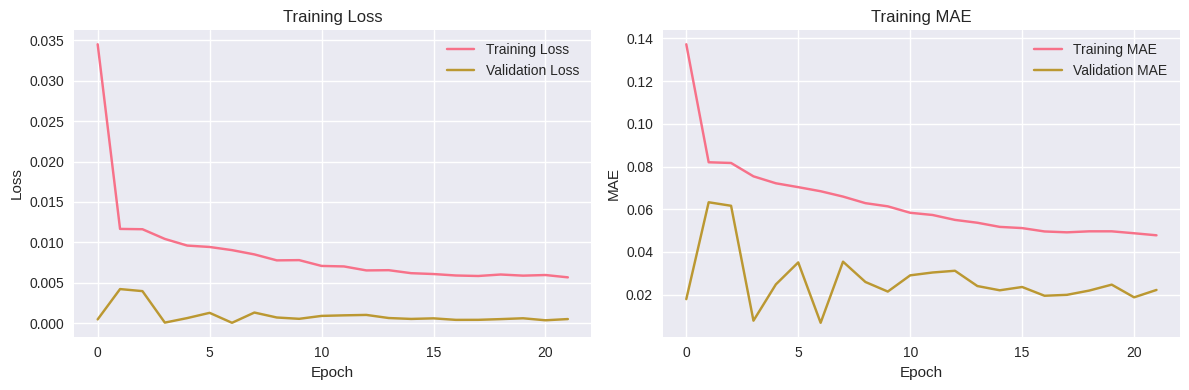

70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

--- Performance Metrics ---
TRAINING SET:
  MSE: 0.005003
  RMSE: 0.070732
  MAE: 0.041674
  MAPE: 2064675.719424
  CE: 40.259168
TEST SET:
  MSE: 0.000307
  RMSE: 0.017523
  MAE: 0.016155
  MAPE: 3.450339
  CE: 7.282016

--- Metric Explanations ---
• MSE: Mean Squared Error - average squared differences (penalizes large errors)
• RMSE: Root Mean Squared Error - MSE in original scale (interpretable)
• MAE: Mean Absolute Error - average absolute differences (robust to outliers)
• MAPE: Mean Absolute Percentage Error - error as percentage (scale-independent)
• CE: Cumulative Error - total bias in predictions (positive = underestimation)


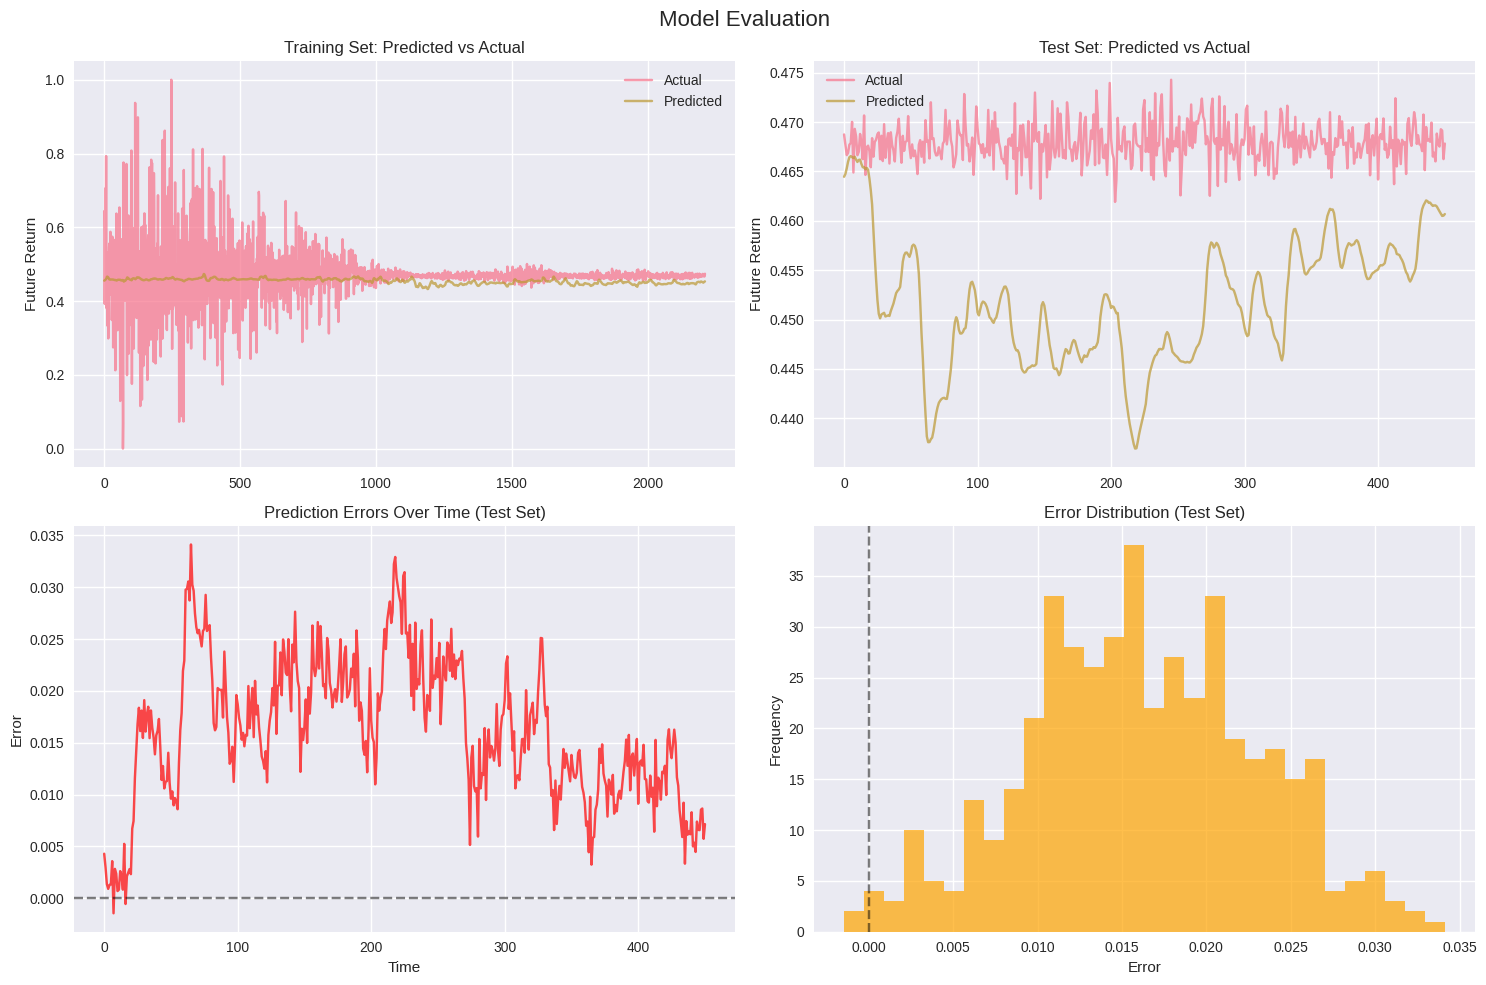


--- Training and Evaluation LTSM for Lookback Period: 60 ---
LSTM Model Architecture:


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 60, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_66 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_67 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_68 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,161 (125.63 KB)

 Trainable params: 32,161 (125.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - loss: 0.0684 - mae: 0.2037 - val_loss: 0.0039 - val_mae: 0.0607 - learning_rate: 0.0010
Epoch 2/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.0130 - mae: 0.0853 - val_loss: 7.3416e-04 - val_mae: 0.0229 - learning_rate: 0.0010
Epoch 3/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - loss: 0.0106 - mae: 0.0757 - val_loss: 0.0064 - val_mae: 0.0783 - learning_rate: 0.0010
Epoch 4/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 0.0097 - mae: 0.0728 - val_loss: 0.0055 - val_mae: 0.0729 - learning_rate: 0.0010
Epoch 5/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 0.0094 - mae: 0.0705 - val_loss: 0.0046 - val_mae: 0.0667 - learning_rate: 0.0010
Epoch 6/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - loss: 0.0082 - mae: 0.0655 - val_loss: 3.5803e-04 - val_mae: 0.0171 - learning_rate: 0.0010
Epoch 7/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.0070 - mae: 0.0597 - val_loss: 0.0042 - val_mae: 0.0646 - learning_rate: 0.001

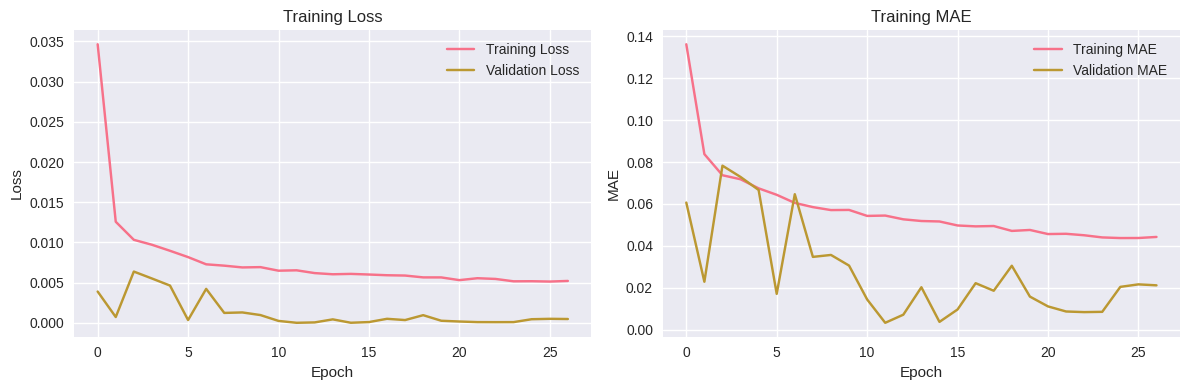

69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

--- Performance Metrics ---
TRAINING SET:
  MSE: 0.004713
  RMSE: 0.068651
  MAE: 0.036537
  MAPE: 2115389.614971
  CE: 26.417996
TEST SET:
  MSE: 0.000037
  RMSE: 0.006061
  MAE: 0.004946
  MAPE: 1.055279
  CE: 1.695551

--- Metric Explanations ---
• MSE: Mean Squared Error - average squared differences (penalizes large errors)
• RMSE: Root Mean Squared Error - MSE in original scale (interpretable)
• MAE: Mean Absolute Error - average absolute differences (robust to outliers)
• MAPE: Mean Absolute Percentage Error - error as percentage (scale-independent)
• CE: Cumulative Error - total bias in predictions (positive = underestimation)


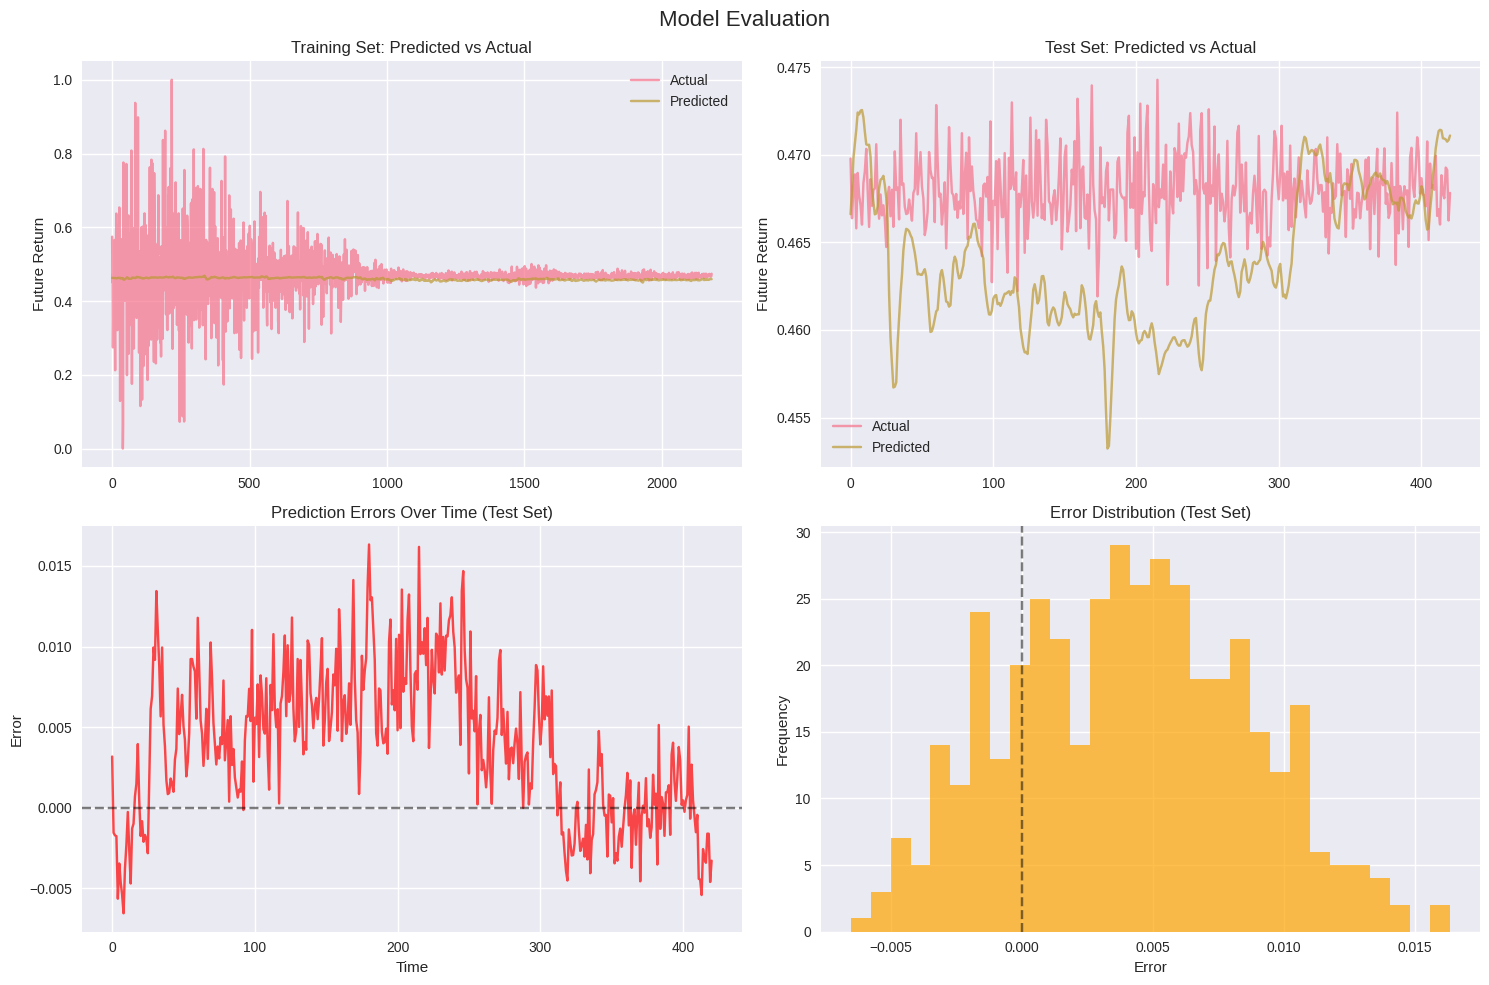


--- Training and Evaluation LTSM for Lookback Period: 90 ---
LSTM Model Architecture:


Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 90, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_69 (Dropout)            │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_70 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_71 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,161 (125.63 KB)

 Trainable params: 32,161 (125.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - loss: 0.0506 - mae: 0.1730 - val_loss: 0.0205 - val_mae: 0.1396 - learning_rate: 0.0010
Epoch 2/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - loss: 0.0111 - mae: 0.0807 - val_loss: 0.0086 - val_mae: 0.0903 - learning_rate: 0.0010
Epoch 3/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - loss: 0.0096 - mae: 0.0741 - val_loss: 0.0013 - val_mae: 0.0270 - learning_rate: 0.0010
Epoch 4/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - loss: 0.0085 - mae: 0.0665 - val_loss: 0.0013 - val_mae: 0.0294 - learning_rate: 0.0010
Epoch 5/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - loss: 0.0077 - mae: 0.0635 - val_loss: 0.0019 - val_mae: 0.0382 - learning_rate: 0.0010
Epoch 6/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0070 - mae: 0.0602 - val_loss: 0.0033 - val_mae: 0.0538 - learning_rate: 0.0010
Epoch 7/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - loss: 0.0071 - mae: 0.0597 - val_loss: 0.0021 - val_mae: 0.0411 - learning_rate: 0.0010
Epo

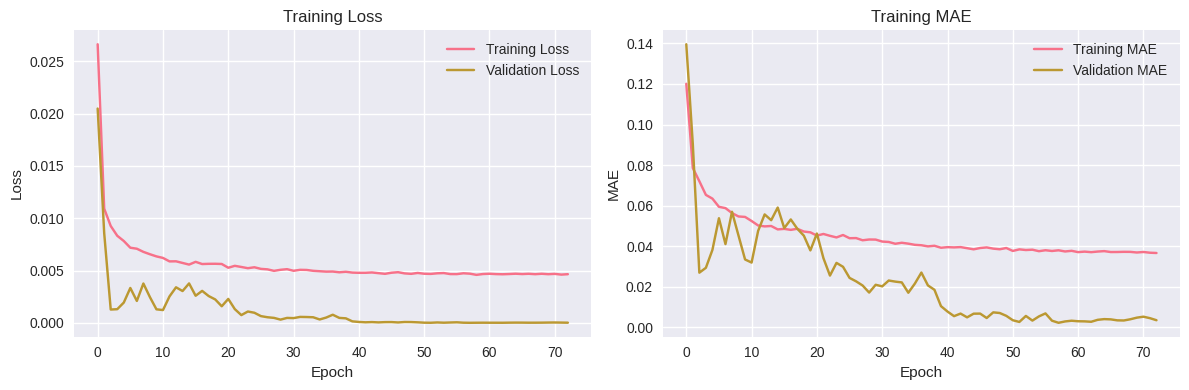

68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

--- Performance Metrics ---
TRAINING SET:
  MSE: 0.004396
  RMSE: 0.066303
  MAE: 0.031298
  MAPE: 2219100.030830
  CE: 0.062719
TEST SET:
  MSE: 0.000008
  RMSE: 0.002823
  MAE: 0.002202
  MAPE: 0.469524
  CE: 0.523787

--- Metric Explanations ---
• MSE: Mean Squared Error - average squared differences (penalizes large errors)
• RMSE: Root Mean Squared Error - MSE in original scale (interpretable)
• MAE: Mean Absolute Error - average absolute differences (robust to outliers)
• MAPE: Mean Absolute Percentage Error - error as percentage (scale-independent)
• CE: Cumulative Error - total bias in predictions (positive = underestimation)


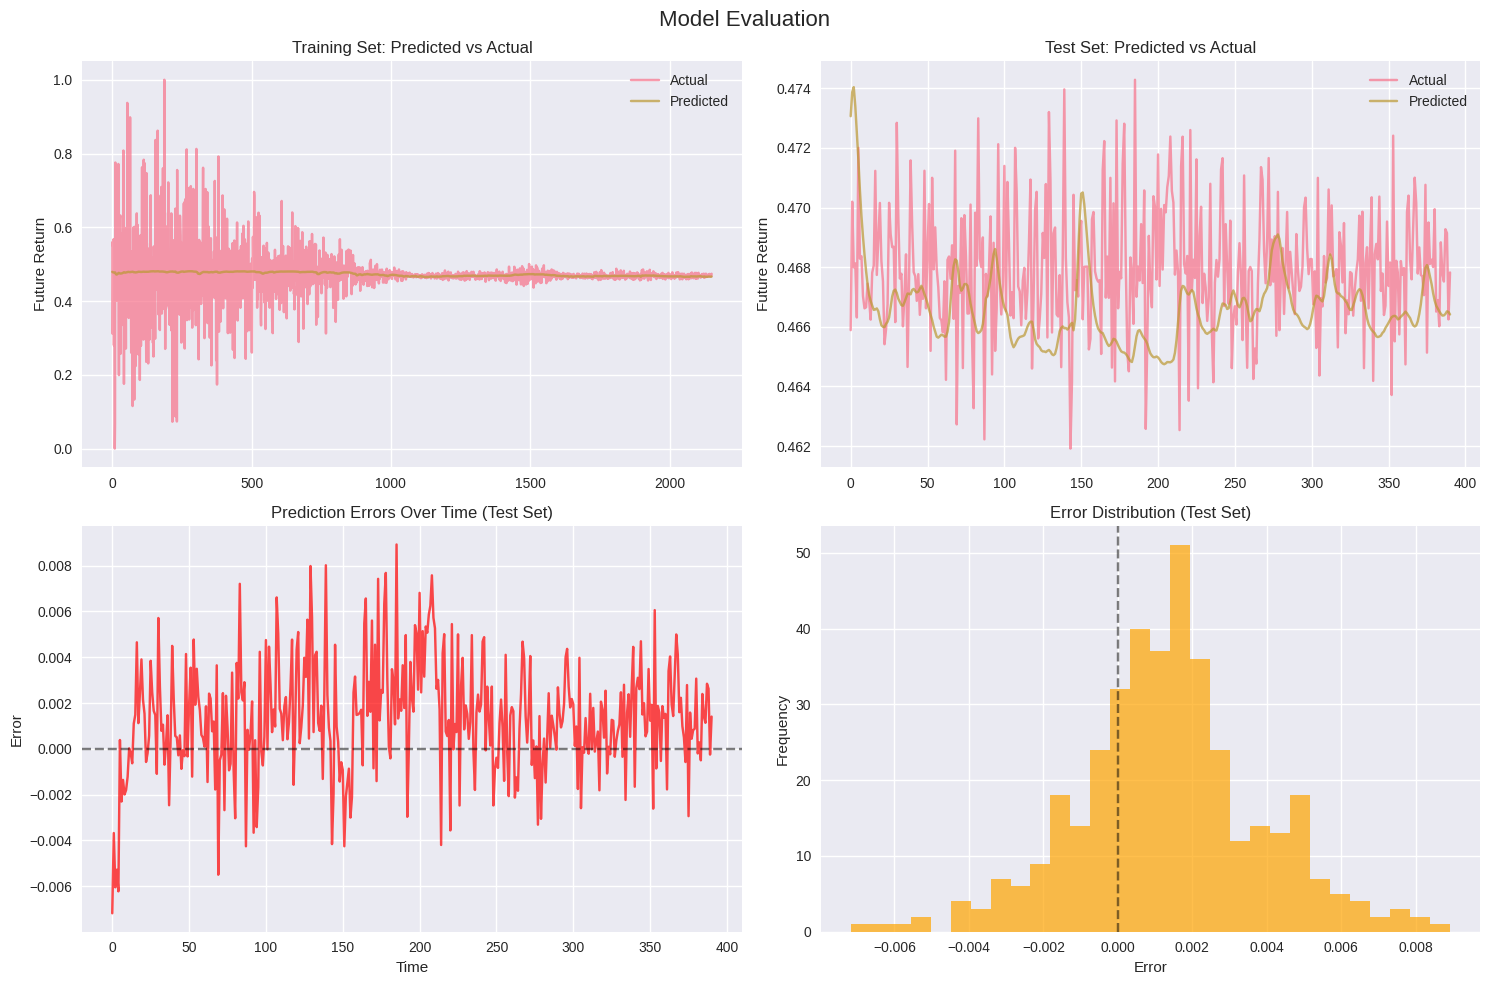

In [213]:
for period, data in datasets.items():
  X_train, y_train = data['X_train'], data['y_train']
  X_val, y_val = data['X_val'], data['y_val']
  X_test, y_test = data['X_test'], data['y_test']

  input_shape = (X_train.shape[1], X_train.shape[2])

  print(f"\n--- Training and Evaluation LTSM for Lookback Period: {period} ---")

  ltsm_model = build_lstm_model(input_shape)
  ltsm_model, ltsm_history = train_model(ltsm_model,
                                        X_train,
                                        y_train,
                                        X_val,
                                        y_val)

  ltsm_test_metrics, ltsm_train_metrics = evaluate_and_visualize(ltsm_model,
                                                                 X_train,
                                                                 y_train,
                                                                 X_test,
                                                                 y_test)